In [1]:
import pandas as pd
import numpy as np

# 1. 1차 정제본 불러오기
df = pd.read_csv('../data/interim/non_english_tv_clean.csv')
df['week'] = pd.to_datetime(df['week'])

# 2. 주차별 TOP 10 총 시청 시간 집계 (거시 지표)
weekly_macro = df.groupby('week')['weekly_hours_viewed'].sum().reset_index()
weekly_macro = weekly_macro.sort_values('week').reset_index(drop=True)

# 3. 4주 단순 이동평균(SMA) 계산
weekly_macro['hours_sma_4w'] = weekly_macro['weekly_hours_viewed'].rolling(window=4).mean()

# 4. 전주 대비 증감률(WoW % Change) 계산
weekly_macro['wow_pct_change'] = weekly_macro['weekly_hours_viewed'].pct_change() * 100

# 5. 최종 가공 데이터 저장 (processed)
processed_path = '../data/processed/01_weekly_macro_series.csv'
weekly_macro.to_csv(processed_path, index=False)

print("=== 주간 거시 지표 가공 완료 ===")
print(f"저장 경로: {processed_path}")
print(f"전체 주차 수: {len(weekly_macro)}주")
weekly_macro.tail(5)

=== 주간 거시 지표 가공 완료 ===
저장 경로: ../data/processed/01_weekly_macro_series.csv
전체 주차 수: 274주


,week,weekly_hours_viewed,hours_sma_4w,wow_pct_change
269,2026-08-30,168600000,193650000.0,-15.020161
270,2026-09-06,183700000,192400000.0,8.956109
271,2026-09-13,172900000,180900000.0,-5.879151
272,2026-09-20,204900000,182525000.0,18.507808
273,2026-09-27,233000000,198625000.0,13.714007


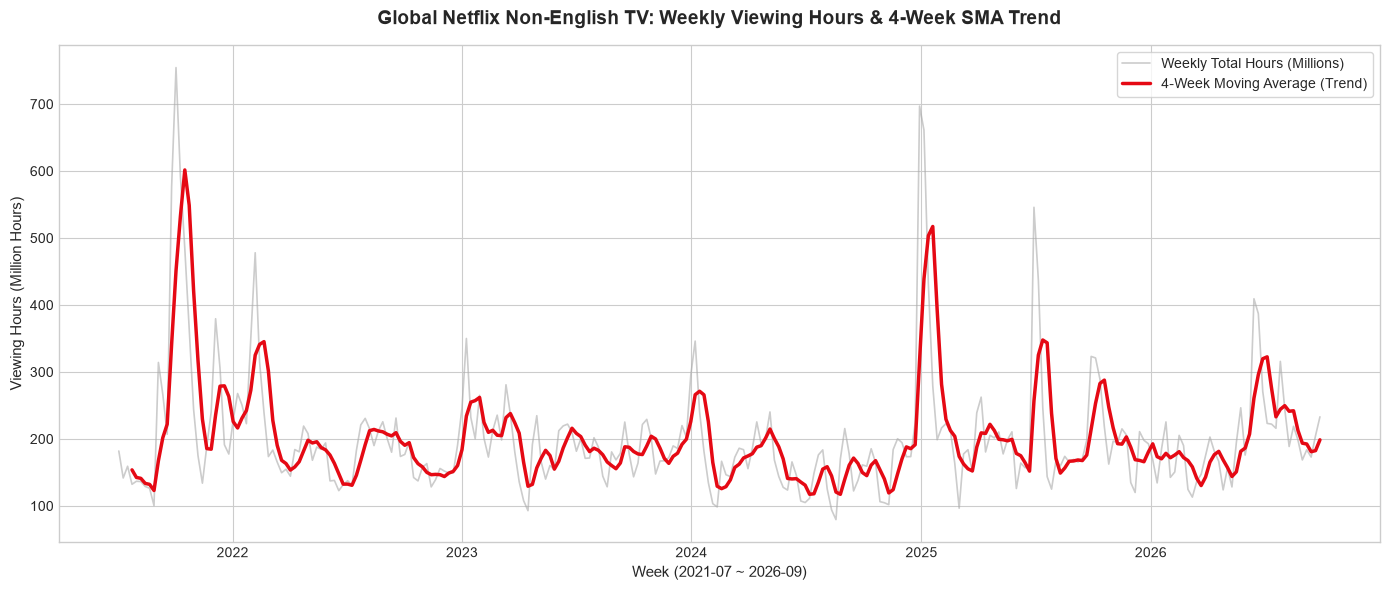

차트 1 저장 완료 -> ../images/01_weekly_trend_sma.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 가공된 주간 거시 데이터 불러오기
macro = pd.read_csv('../data/processed/01_weekly_macro_series.csv')
macro['week'] = pd.to_datetime(macro['week'])

# 2. 12주 이동평균(분기 추세선) 추가 계산
macro['hours_sma_12w'] = macro['weekly_hours_viewed'].rolling(window=12).mean()

# 3. 선 3개 시각화 그리기
plt.figure(figsize=(14, 6))

# [선 1] 실제 주간 시청 시간 (Raw Data)
plt.plot(macro['week'], macro['weekly_hours_viewed'] / 1e6, 
         color='#CCCCCC', alpha=0.6, linewidth=1.2, label='Weekly Total (Raw Hours)')

# [선 2] 4주 이동평균 (단기/월간 흐름)
plt.plot(macro['week'], macro['hours_sma_4w'] / 1e6, 
         color='#2B5C8F', linewidth=2.0, label='4-Week Moving Average (Short-term)')

# [선 3] 12주 이동평균 (장기/분기 거시 트렌드)
plt.plot(macro['week'], macro['hours_sma_12w'] / 1e6, 
         color='#E50914', linewidth=2.8, label='12-Week Moving Average (Quarterly Macro Trend)')

# 타이틀 및 축 설정
plt.title('Global Netflix Non-English TV: 3-Line Viewership & Multi-Span Moving Average Trend', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Week (2021-07 ~ 2026-09)', fontsize=11)
plt.ylabel('Viewing Hours (Million Hours)', fontsize=11)
plt.legend(frameon=True, facecolor='white', fontsize=11, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# 4. 차트 1번 덮어쓰기 저장
chart1_path = '../images/01_weekly_trend_sma.png'
plt.savefig(chart1_path, dpi=300)
plt.show()

print(f"선 3개 그래프 완성 및 저장 완료 -> {chart1_path}")

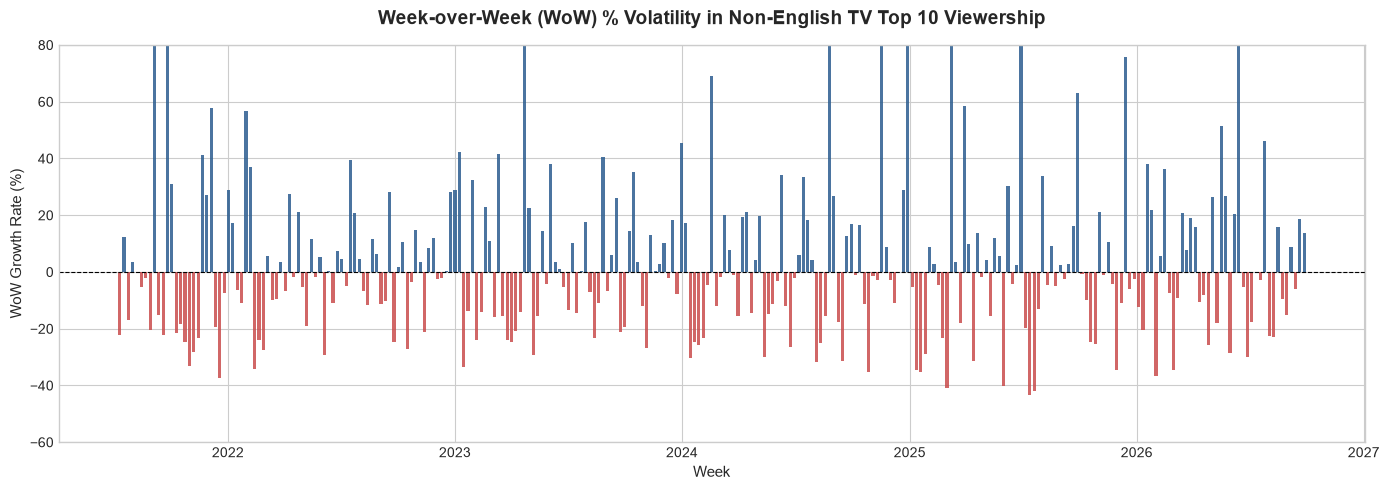

차트 2 저장 완료 -> ../images/02_wow_volatility_bar.png


In [3]:
plt.figure(figsize=(14, 5))

# 양수(상승 주차)는 소프트 블루, 음수(하락 주차)는 소프트 레드로 구분
colors = ['#2b5c8f' if val >= 0 else '#c94c4c' for val in weekly_macro['wow_pct_change']]

plt.bar(weekly_macro['week'], weekly_macro['wow_pct_change'], color=colors, width=5, alpha=0.85)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.title('Week-over-Week (WoW) % Volatility in Non-English TV Top 10 Viewership', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Week', fontsize=11)
plt.ylabel('WoW Growth Rate (%)', fontsize=11)
plt.ylim(-60, 80)
plt.tight_layout()

# 이미지 저장
chart2_path = '../images/02_wow_volatility_bar.png'
plt.savefig(chart2_path, dpi=300)
plt.show()
print(f"차트 2 저장 완료 -> {chart2_path}")